# Vector Distribution Explorer — `georgian_legal`

Visualizes how the BGE-M3 dense embeddings stored in **Qdrant** are distributed across the
Georgian legal corpus. Each point in the collection is **one chunk** of a legal document
(1024-d, cosine / unit-normalized).

**What this notebook shows**
1. Corpus overview — point counts, document-type & status breakdowns, token-length & vector-norm sanity checks
2. 2D projections (PCA, UMAP, t-SNE) colored by `document_type` and `status`
3. Interactive Plotly scatter with hover (title / heading / status)
4. 3D PCA scatter
5. KMeans clustering + cluster×document_type composition
6. Similarity structure — nearest-neighbour cosine distribution & intra/inter-type similarity

**Prerequisites**
- Qdrant running locally: `cd ingest && docker compose up -d`
- Run with the `ingest/.venv` Python 3.12 kernel (has `qdrant-client`, `numpy`, `pandas`, `scikit-learn`, `umap-learn`, `matplotlib`, `plotly`).


## 0 · Setup

In [1]:
# If running outside the ingest/.venv kernel, uncomment to install:
# %pip install qdrant-client numpy pandas scikit-learn umap-learn matplotlib plotly

import sys, os
from pathlib import Path

# Make the project's `ingest` package importable so we reuse its config & client.
# Notebook lives in ingest/notebooks/ -> parent of parent is the repo root.
NB_DIR = Path.cwd()
INGEST_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
if str(INGEST_ROOT) not in sys.path:
    sys.path.insert(0, str(INGEST_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option("display.max_colwidth", 60)
print("python:", sys.version.split()[0])
print("ingest root:", INGEST_ROOT)


python: 3.12.12
ingest root: /Users/bezhomatiashvili/Desktop/matsne_scraping/ingest


In [2]:
# Connect straight to Qdrant. We deliberately DON'T import the `ingest` package here: its
# qdrant_store pulls in FlagEmbedding/torch (heavy, embedding-only) which a viz notebook never
# needs. This keeps the notebook runnable on any kernel that just has `qdrant-client`.
import os
from types import SimpleNamespace

# Honour ingest/.env if python-dotenv is available; otherwise fall back to env vars / defaults.
try:
    from dotenv import load_dotenv
    load_dotenv(INGEST_ROOT / ".env")
except ModuleNotFoundError:
    pass

cfg = SimpleNamespace(
    qdrant_url=os.getenv("QDRANT_URL", "http://localhost:6333"),
    qdrant_api_key=os.getenv("QDRANT_API_KEY") or None,
    collection_name=os.getenv("COLLECTION_NAME", "georgian_legal"),
    embed_model=os.getenv("EMBED_MODEL", "BAAI/bge-m3"),
    dense_dim=int(os.getenv("DENSE_DIM", "1024")),
)

from qdrant_client import QdrantClient
client = QdrantClient(url=cfg.qdrant_url, api_key=cfg.qdrant_api_key, timeout=120)

info = client.get_collection(cfg.collection_name)
print(f"collection : {cfg.collection_name}")
print(f"status     : {info.status}")
print(f"points     : {info.points_count}")
print(f"dense dim  : {cfg.dense_dim}  ({cfg.embed_model}, distance={info.config.params.vectors['dense'].distance})")


collection : georgian_legal
status     : green
points     : 2566
dense dim  : 1024  (BAAI/bge-m3, distance=Cosine)


## 1 · Load all dense vectors + payload

In [3]:
# Scroll the whole collection, pulling the named "dense" vector and the payload fields we
# colour/facet by. 2.5k points fits comfortably in memory.
PAYLOAD_FIELDS = ["document_type", "status", "language", "court", "title",
                  "heading", "token_count", "date", "document_id", "chunk_index"]

def load_all(client, collection, page=512):
    vectors, rows, ids, offset = [], [], [], None
    while True:
        batch, offset = client.scroll(
            collection_name=collection,
            with_vectors=["dense"], with_payload=PAYLOAD_FIELDS,
            limit=page, offset=offset,
        )
        for p in batch:
            v = p.vector["dense"] if isinstance(p.vector, dict) else p.vector
            vectors.append(v)
            ids.append(p.id)
            rows.append({k: p.payload.get(k) for k in PAYLOAD_FIELDS})
        if offset is None:
            break
    return np.asarray(vectors, dtype=np.float32), pd.DataFrame(rows), ids

X, meta, point_ids = load_all(client, cfg.collection_name)
meta["norm"] = np.linalg.norm(X, axis=1)
print("vectors:", X.shape, "| metadata:", meta.shape)
meta.head()


vectors: (2566, 1024) | metadata: (2566, 11)


,document_type,status,language,court,title,heading,token_count,date,document_id,chunk_index,norm
0,საქართველოს მინისტრის ბრძანება,in_force,ka,None,საქართველოს იუსტიციის სამინისტროს ადმინისტრაციის (დეპარტ...,საქართველოს იუსტიციის სამინისტროს ადმინისტრაციის (დეპარტ...,493,2020-11-26T00:00:00Z,5037454,6,1.0
1,საქართველოს მთავრობის დადგენილება,in_force,ka,None,კულტურული მემკვიდრეობის ძეგლისათვის − ქ. თბილისის ზ. ფალ...,NaN,13,2018-06-12T00:00:00Z,4221214,0,1.0
2,ავტონომიური რესპუბლიკის მთავრობის დადგენილება,in_force,ka,None,საჯარო სამართლის იურიდიული პირის - ახალგაზრდობის რეგიონუ...,საჯარო სამართლის იურიდიული პირის - ახალგაზრდობის რეგიონუ...,476,2019-05-10T00:00:00Z,4556678,4,1.0
3,აფხაზეთის ავტონომიური რესპუბლიკის აფხაზეთის ავტონომიური ...,repealed,ka,None,აფხაზეთის ავტონომიური რესპუბლიკის აფხაზეთის ავტონომიური ...,აფხაზეთის ავტონომიური რესპუბლიკის აფხაზეთის ავტონომიური ...,507,2020-02-04T00:00:00Z,4786727,7,1.0
4,საქართველოს მინისტრის ბრძანება,in_force,ka,None,„საჯარო სამართლის იურიდიული პირის - საქართველოს შინაგან ...,„საჯარო სამართლის იურიდიული პირის – საქართველოს შინაგან ...,110,2018-12-13T00:00:00Z,4378284,1,1.0


## 2 · Corpus overview

In [4]:
# Categorical breakdowns of what's actually in the index.
print("Documents (unique document_id):", meta["document_id"].nunique())
print("Chunks (points)              :", len(meta))
print()
print("By status:")
print(meta["status"].value_counts(dropna=False).to_string())
print()
print("By document_type (top 12):")
print(meta["document_type"].fillna("None").value_counts().head(12).to_string())


Documents (unique document_id): 318
Chunks (points)              : 2566

By status:
status
in_force    1669
repealed     897

By document_type (top 12):
document_type
საქართველოს მინისტრის ბრძანება                                            741
საქართველოს კანონი                                                        677
საქართველოს მთავრობის დადგენილება                                         401
საქართველოს იუსტიციის უმაღლესი საბჭოს დადგენილება                         225
ავტონომიური რესპუბლიკის მთავრობის დადგენილება                             126
ნორმატიული აქტების პროექტები                                               64
საქართველოს გენერალური პროკურორის ბრძანება                                 54
მუნიციპალიტეტისა და თვითმმართველი ქალაქის საკრებულოს დადგენილება           40
ავტონომიური რესპუბლიკის უმაღლესი წარმომადგენლობითი ორგანოს დადგენილება     38
ავტონომიური რესპუბლიკის უმაღლესი წარმომადგენლობითი ორგანოს რეგლამენტი      37
საქართველოს სსრ უმაღლესი საბჭოს პრეზიდიუმის ბრძანებულ

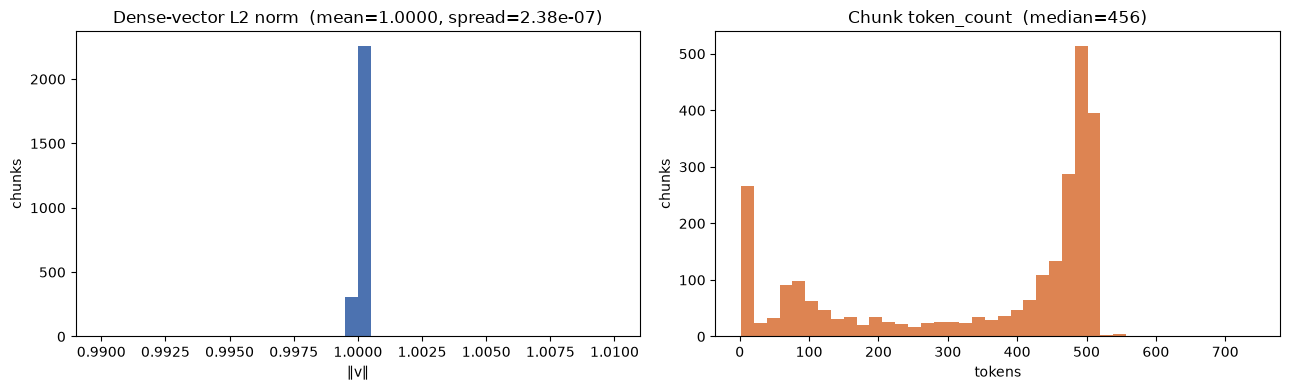

In [5]:
# Sanity checks: vector norms (should be ~1.0 for cosine) and chunk token-length spread.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# BGE-M3 dense vectors are unit-normalized, so norms collapse onto ~1.0 (near-zero range).
# Give an explicit window so the histogram still renders when the spread is degenerate.
nspread = meta["norm"].max() - meta["norm"].min()
nrange = None if nspread > 1e-6 else (meta["norm"].mean() - 0.01, meta["norm"].mean() + 0.01)
ax[0].hist(meta["norm"], bins=40, range=nrange, color="#4c72b0")
ax[0].set_title(f"Dense-vector L2 norm  (mean={meta['norm'].mean():.4f}, spread={nspread:.2e})")
ax[0].set_xlabel("‖v‖"); ax[0].set_ylabel("chunks")

tok = pd.to_numeric(meta["token_count"], errors="coerce").dropna()
ax[1].hist(tok, bins=40, color="#dd8452")
ax[1].set_title(f"Chunk token_count  (median={tok.median():.0f})")
ax[1].set_xlabel("tokens"); ax[1].set_ylabel("chunks")
plt.tight_layout(); plt.show()


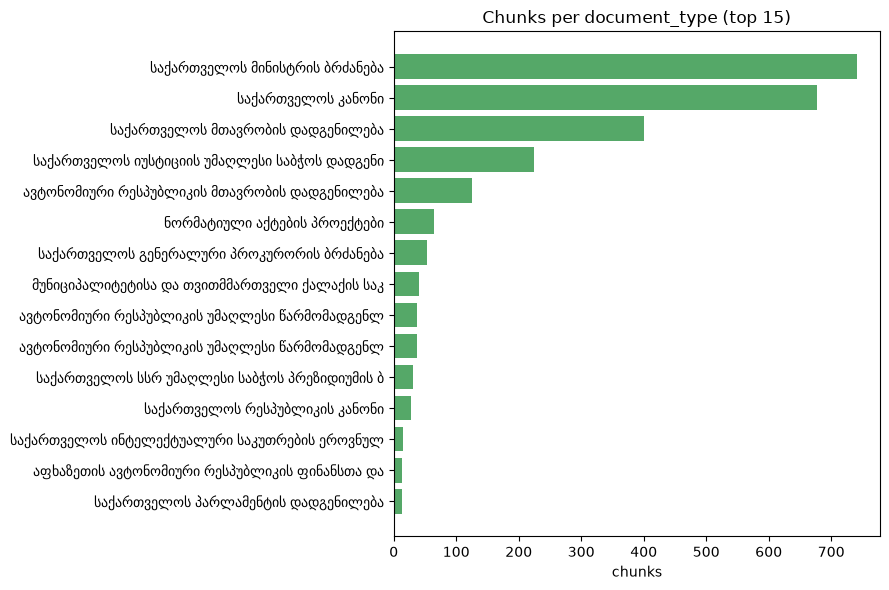

In [6]:
# Document-type distribution as a horizontal bar (Georgian labels render fine in matplotlib if
# a Unicode font is available; the interactive Plotly charts below are the reliable view).
counts = meta["document_type"].fillna("None").value_counts().head(15)[::-1]
plt.figure(figsize=(9, 6))
plt.barh(range(len(counts)), counts.values, color="#55a868")
plt.yticks(range(len(counts)), [s[:45] for s in counts.index])
plt.xlabel("chunks"); plt.title("Chunks per document_type (top 15)")
plt.tight_layout(); plt.show()


## 3 · Dimensionality reduction

We project the 1024-d vectors to 2D three ways and compare:
- **PCA** — linear, fast, preserves global variance structure.
- **UMAP** — non-linear, good at exposing local cluster structure.
- **t-SNE** — non-linear, emphasises local neighbourhoods (run on a PCA-50 pre-reduction for speed).

All three run on the full set. Since the vectors are unit-normalized, cosine geometry ≈ Euclidean here.

In [7]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

RANDOM_STATE = 42

# PCA: keep 50 comps for downstream t-SNE; also grab the first 3 for direct plotting.
pca50 = PCA(n_components=50, random_state=RANDOM_STATE).fit(X)
X_pca50 = pca50.transform(X)
emb_pca = X_pca50[:, :2]
emb_pca3d = X_pca50[:, :3]
print(f"PCA: top-2 explain {pca50.explained_variance_ratio_[:2].sum()*100:.1f}% | "
      f"top-50 explain {pca50.explained_variance_ratio_.sum()*100:.1f}% of variance")

emb_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine",
                     random_state=RANDOM_STATE).fit_transform(X)
print("UMAP done:", emb_umap.shape)

perplexity = min(30, max(5, (len(X) - 1) // 3))
emb_tsne = TSNE(n_components=2, perplexity=perplexity, init="pca",
                random_state=RANDOM_STATE).fit_transform(X_pca50)
print("t-SNE done:", emb_tsne.shape, f"(perplexity={perplexity})")


/Users/bezhomatiashvili/Desktop/matsne_scraping/ingest/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PCA: top-2 explain 12.3% | top-50 explain 62.1% of variance


/Users/bezhomatiashvili/Desktop/matsne_scraping/ingest/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done: (2566, 2)


t-SNE done: (2566, 2) (perplexity=30)


In [8]:
# Attach projections to the metadata frame for easy plotting.
for name, emb in [("pca", emb_pca), ("umap", emb_umap), ("tsne", emb_tsne)]:
    meta[f"{name}_x"], meta[f"{name}_y"] = emb[:, 0], emb[:, 1]

# Short label for legends/hover (full Georgian type names are long).
meta["type_short"] = meta["document_type"].fillna("None").str.slice(0, 28)


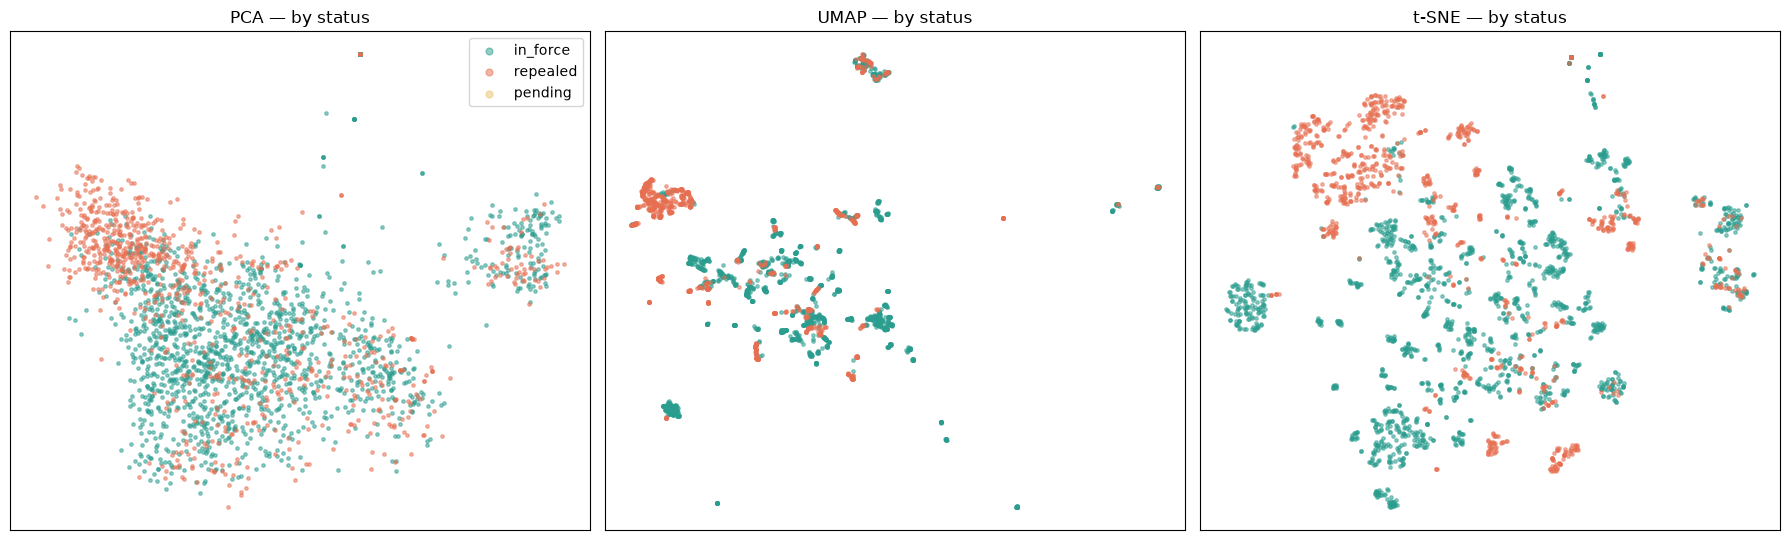

In [9]:
# Side-by-side static comparison of the three projections, coloured by status.
proj = [("PCA", "pca"), ("UMAP", "umap"), ("t-SNE", "tsne")]
status_colors = {"in_force": "#2a9d8f", "repealed": "#e76f51", "pending": "#e9c46a"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (title, key) in zip(axes, proj):
    for st, c in status_colors.items():
        m = meta["status"] == st
        ax.scatter(meta.loc[m, f"{key}_x"], meta.loc[m, f"{key}_y"],
                   s=6, alpha=0.5, c=c, label=st)
    ax.set_title(f"{title} — by status"); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(markerscale=2, loc="best")
plt.tight_layout(); plt.show()


## 4 · 2D point maps

The big static view of how the chunks sit in 2D, colored by `document_type` (the richest
categorical) and by `status`. These are **matplotlib** raster plots, so they render everywhere —
including the VS Code notebook viewer, which has WebGL disabled and can't show Plotly's GL traces.
An interactive Plotly version (hover = title/heading) is exported to a standalone HTML at the end
of this section; open it in a browser for pan/zoom/hover.

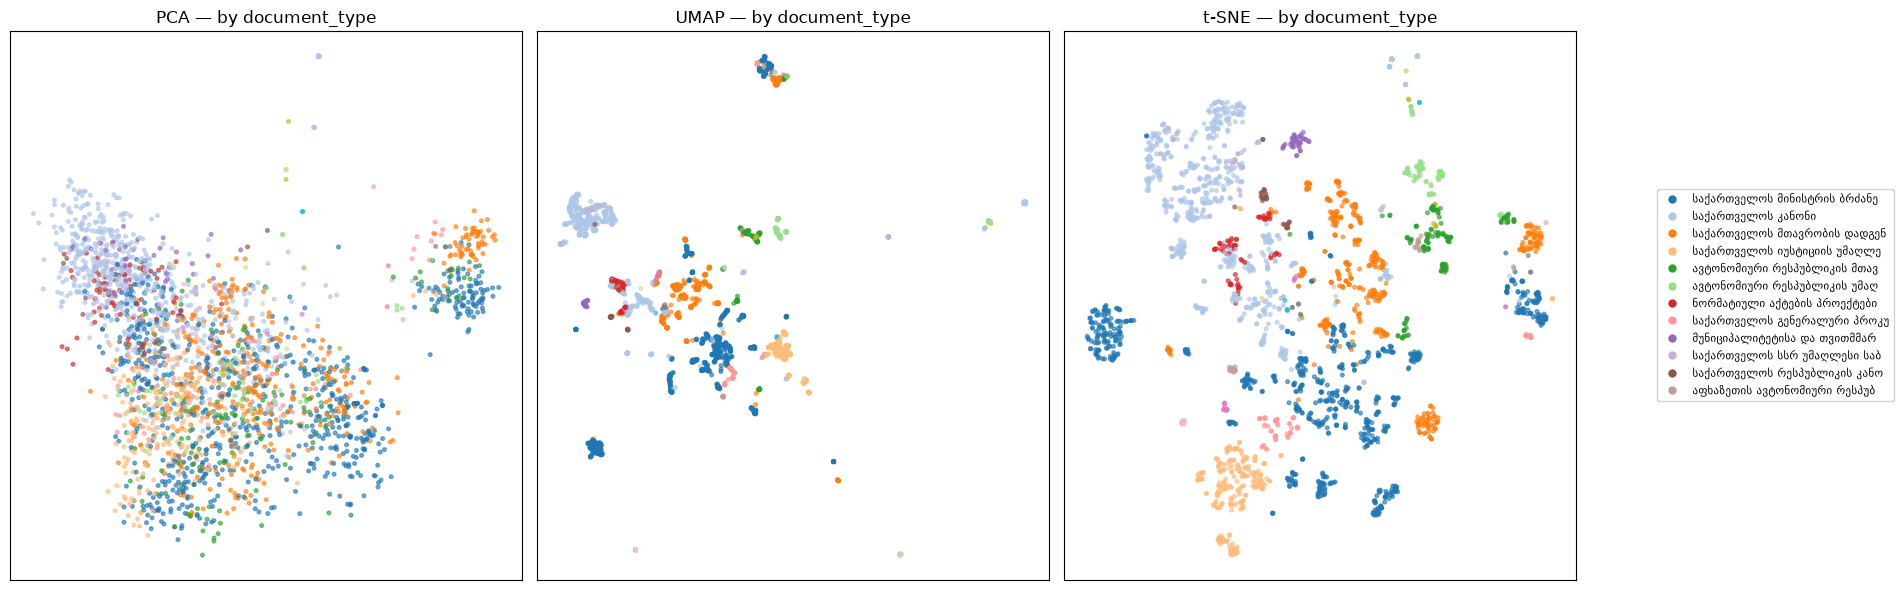

In [10]:
# Static 2D scatter, one panel per projection, coloured by document_type.
# A stable colour per type so the three panels and the 3D plots below all agree.
import matplotlib.cm as cm
types_sorted = meta["type_short"].value_counts().index.tolist()
type_color = {t: cm.tab20(i % 20) for i, t in enumerate(types_sorted)}
meta["_c"] = meta["type_short"].map(type_color)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (title, key) in zip(axes, [("PCA", "pca"), ("UMAP", "umap"), ("t-SNE", "tsne")]):
    ax.scatter(meta[f"{key}_x"], meta[f"{key}_y"], s=7, alpha=0.6, c=meta["_c"].tolist())
    ax.set_title(f"{title} — by document_type"); ax.set_xticks([]); ax.set_yticks([])
# Shared legend (top 12 types) to the right.
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker="o", ls="", mfc=type_color[t], mec="none", label=t[:32])
           for t in types_sorted[:12]]
fig.legend(handles=handles, loc="center right", fontsize=8, framealpha=0.9)
plt.tight_layout(rect=[0, 0, 0.84, 1]); plt.show()


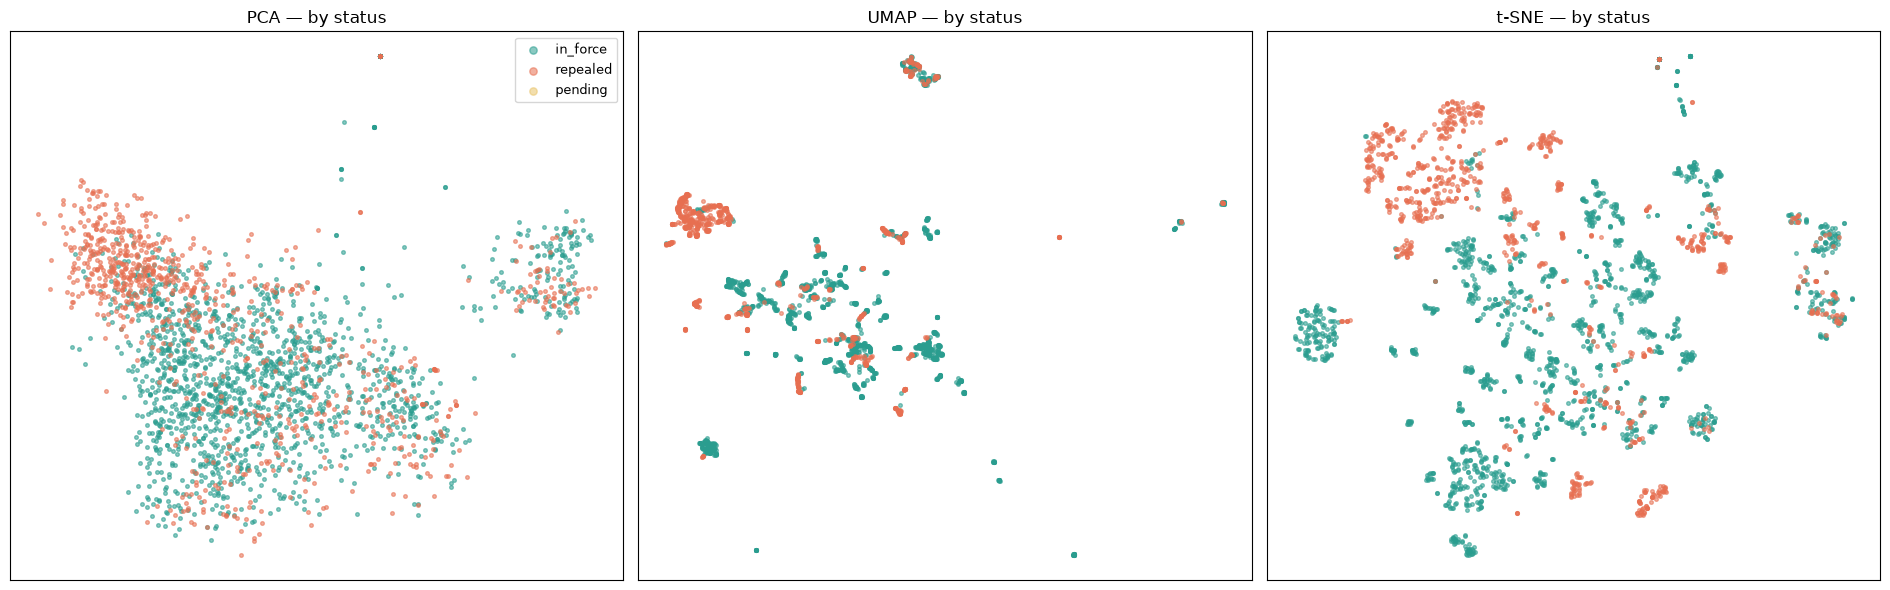

In [11]:
# Same three projections coloured by status (in-force vs repealed) — the cleaner binary split.
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, (title, key) in zip(axes, [("PCA", "pca"), ("UMAP", "umap"), ("t-SNE", "tsne")]):
    for st, c in status_colors.items():
        m = meta["status"] == st
        ax.scatter(meta.loc[m, f"{key}_x"], meta.loc[m, f"{key}_y"],
                   s=7, alpha=0.55, c=c, label=st)
    ax.set_title(f"{title} — by status"); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(markerscale=2, fontsize=9)
plt.tight_layout(); plt.show()


In [12]:
# Interactive 2D (Plotly). render_mode="svg" forces non-WebGL SVG so it renders inline in VS
# Code even above 1000 points (Plotly would otherwise switch to a WebGL trace and show the
# "WebGL is not supported" box). Also exported to HTML as a fallback.
import plotly.io as pio

proj_key = "umap"  # try "pca" or "tsne" too
plot_df = meta.copy()
plot_df["title_short"] = plot_df["title"].fillna("").str.slice(0, 70)
plot_df["heading_short"] = plot_df["heading"].fillna("").str.slice(0, 70)

fig2d = px.scatter(
    plot_df, x=f"{proj_key}_x", y=f"{proj_key}_y", color="type_short",
    render_mode="svg",
    hover_data={"title_short": True, "heading_short": True, "status": True,
                f"{proj_key}_x": False, f"{proj_key}_y": False, "type_short": False},
    opacity=0.7, height=680,
    title=f"{proj_key.upper()} — {len(plot_df)} chunks by document_type (interactive)",
)
fig2d.update_traces(marker=dict(size=5))
fig2d.update_layout(legend=dict(font=dict(size=10), itemsizing="constant"),
                    xaxis_title=None, yaxis_title=None)

out2d = NB_DIR / "vector_2d_interactive.html"
fig2d.write_html(str(out2d), include_plotlyjs="cdn")
print("Interactive 2D also saved to:", out2d)
fig2d.show()


Interactive 2D also saved to: /Users/bezhomatiashvili/Desktop/matsne_scraping/ingest/notebooks/vector_2d_interactive.html


## 5 · 3D point clouds

The first three PCA components as a 3D cloud. Shown as **static matplotlib** 3D scatters (which
render inline) from a couple of fixed viewing angles, colored by `document_type` and by `status`.
For a fully rotatable WebGL version, the last cell writes a standalone `vector_3d_interactive.html`
— open it in Chrome/Safari (browsers support WebGL; the VS Code viewer does not).

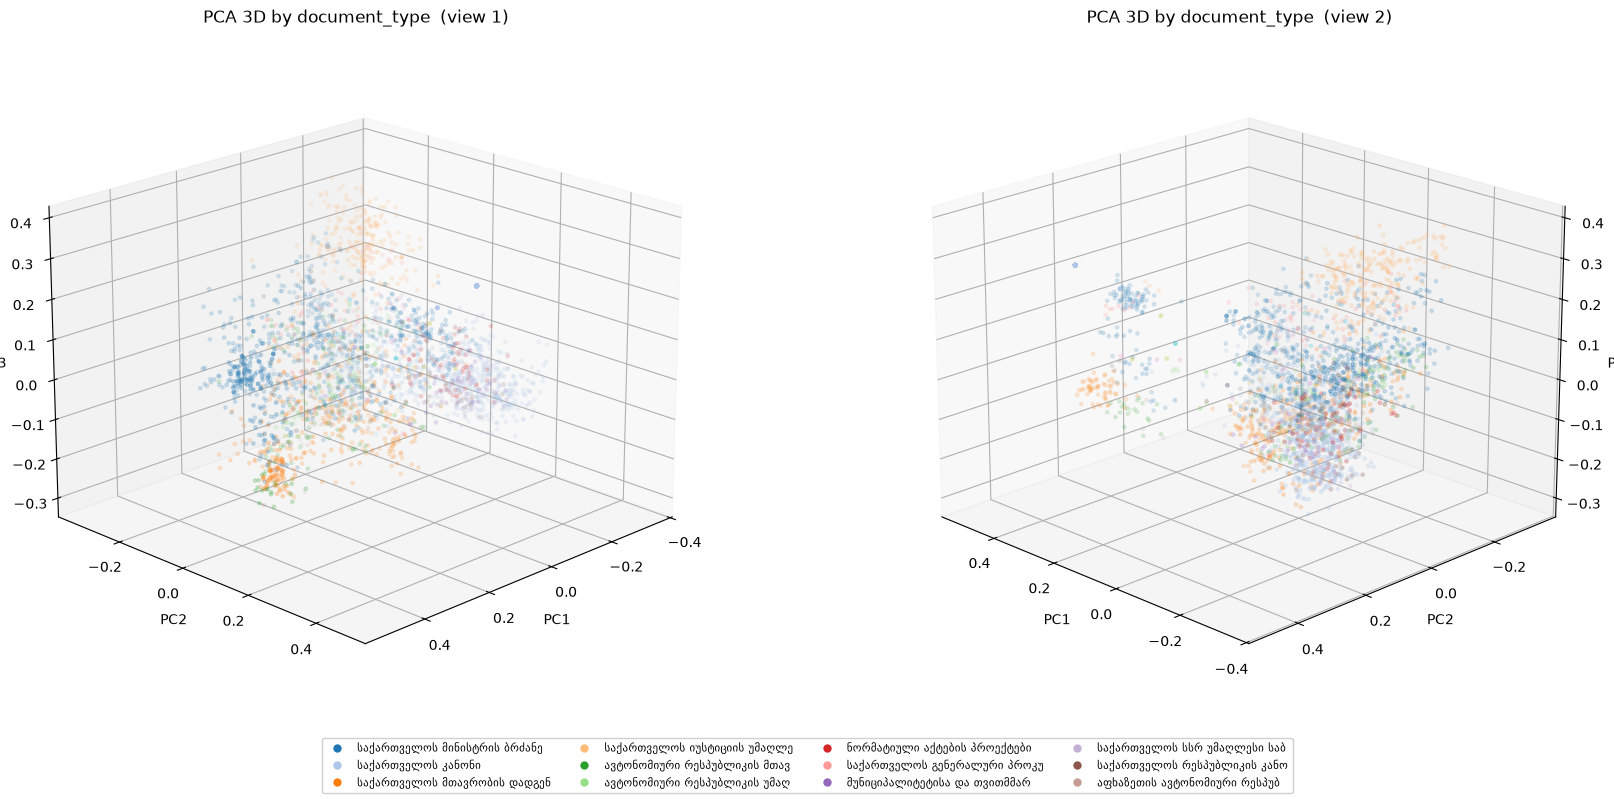

In [13]:
# Static 3D scatter (matplotlib) — top-3 PCA components, coloured by document_type.
# Two camera angles so structure is readable without interactive rotation.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)

xs, ys, zs = emb_pca3d[:, 0], emb_pca3d[:, 1], emb_pca3d[:, 2]
fig = plt.figure(figsize=(18, 8))
for idx, (elev, azim) in enumerate([(20, 45), (20, 135)]):
    ax = fig.add_subplot(1, 2, idx + 1, projection="3d")
    ax.scatter(xs, ys, zs, s=6, alpha=0.5, c=meta["_c"].tolist())
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"PCA 3D by document_type  (view {idx+1})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
handles = [Line2D([0], [0], marker="o", ls="", mfc=type_color[t], mec="none", label=t[:30])
           for t in types_sorted[:12]]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=8, framealpha=0.9)
plt.tight_layout(rect=[0, 0.08, 1, 1]); plt.show()


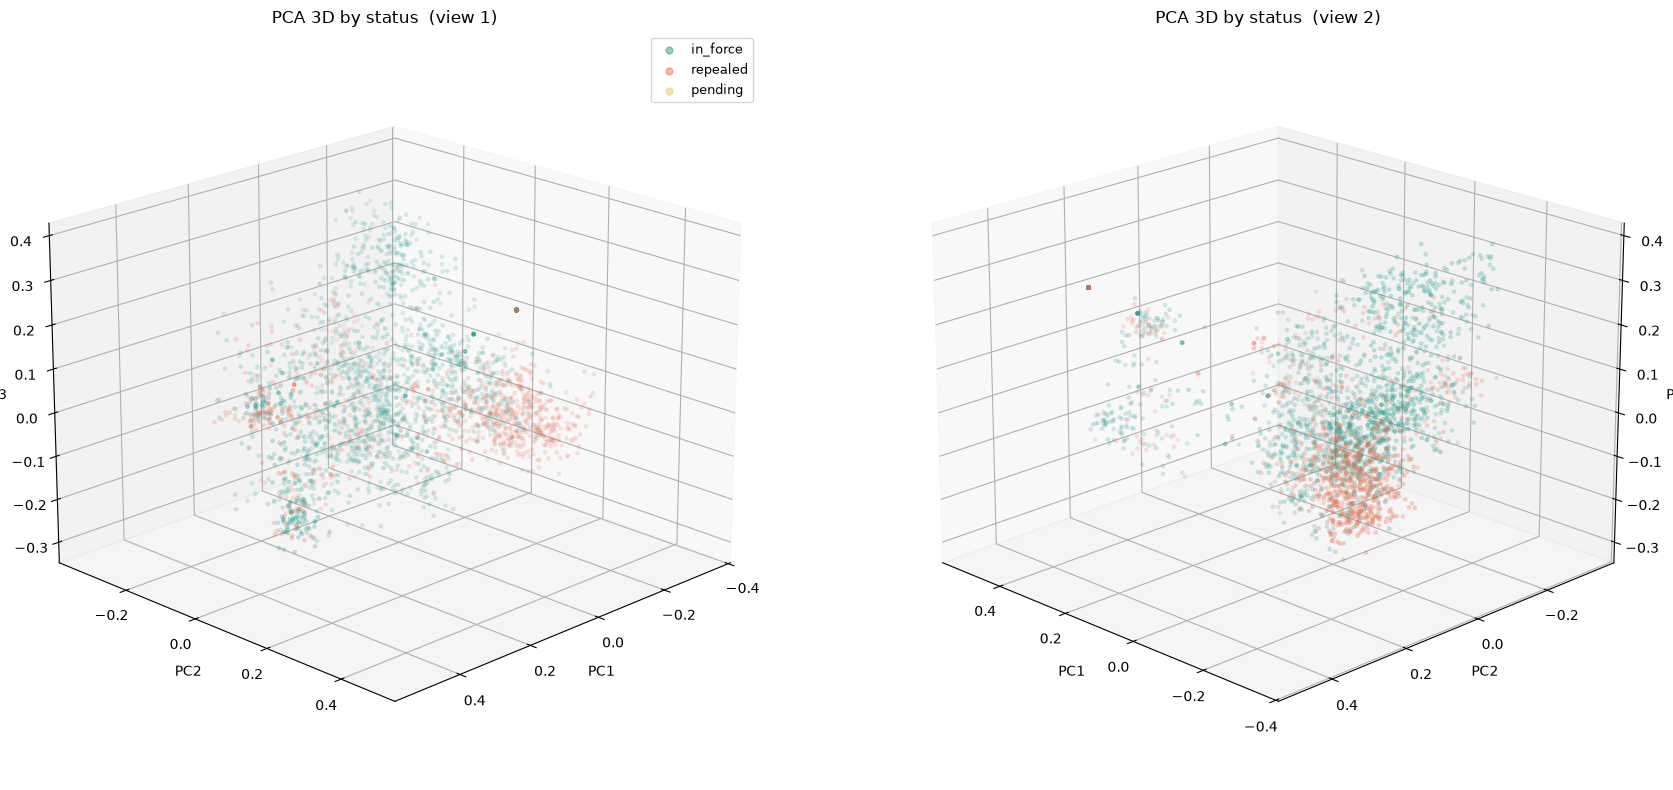

In [14]:
# Same 3D cloud coloured by status.
fig = plt.figure(figsize=(18, 8))
for idx, (elev, azim) in enumerate([(20, 45), (20, 135)]):
    ax = fig.add_subplot(1, 2, idx + 1, projection="3d")
    for st, c in status_colors.items():
        m = (meta["status"] == st).values
        ax.scatter(xs[m], ys[m], zs[m], s=6, alpha=0.5, c=c, label=st)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"PCA 3D by status  (view {idx+1})")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    if idx == 0:
        ax.legend(markerscale=2, fontsize=9)
plt.tight_layout(); plt.show()


In [15]:
# Fully interactive (rotatable) 3D — written to a standalone HTML so WebGL runs in your browser,
# not the VS Code viewer. We do NOT call fig.show() here (that would hit the WebGL-less renderer);
# open the printed file path in Chrome/Safari instead.
df3d = meta.copy()
df3d["pca_z"] = emb_pca3d[:, 2]
df3d["title_short"] = df3d["title"].fillna("").str.slice(0, 60)
fig3d = px.scatter_3d(
    df3d, x="pca_x", y="pca_y", z="pca_z", color="type_short",
    opacity=0.65, height=760,
    hover_data={"title_short": True, "status": True,
                "pca_x": False, "pca_y": False, "pca_z": False, "type_short": False},
    title="Top-3 principal components (interactive 3D)",
)
fig3d.update_traces(marker=dict(size=3))
fig3d.update_layout(legend=dict(font=dict(size=9), itemsizing="constant"))

out3d = NB_DIR / "vector_3d_interactive.html"
fig3d.write_html(str(out3d), include_plotlyjs="cdn")
print("Interactive rotatable 3D written to:")
print(" ", out3d)
print("Open that file in Chrome/Safari for full WebGL rotation & hover.")


Interactive rotatable 3D written to:
  /Users/bezhomatiashvili/Desktop/matsne_scraping/ingest/notebooks/vector_3d_interactive.html
Open that file in Chrome/Safari for full WebGL rotation & hover.


## 6 · KMeans clustering

Cluster the full-dimensional vectors, pick *k* by silhouette score, then cross-tabulate the
clusters against `document_type` to see whether the embedding geometry recovers the legal
taxonomy on its own.

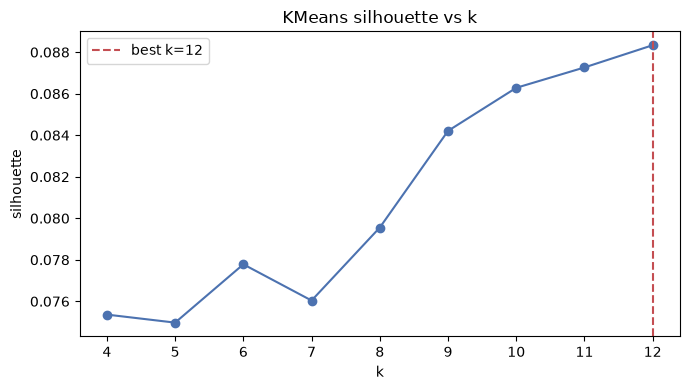

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = list(range(4, 13))
sils = []
for k in ks:
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X)
    sils.append(silhouette_score(X, labels, sample_size=min(2000, len(X)),
                                 random_state=RANDOM_STATE))
best_k = ks[int(np.argmax(sils))]

plt.figure(figsize=(7, 4))
plt.plot(ks, sils, "o-", color="#4c72b0")
plt.axvline(best_k, ls="--", c="#c44e52", label=f"best k={best_k}")
plt.xlabel("k"); plt.ylabel("silhouette"); plt.title("KMeans silhouette vs k")
plt.legend(); plt.tight_layout(); plt.show()


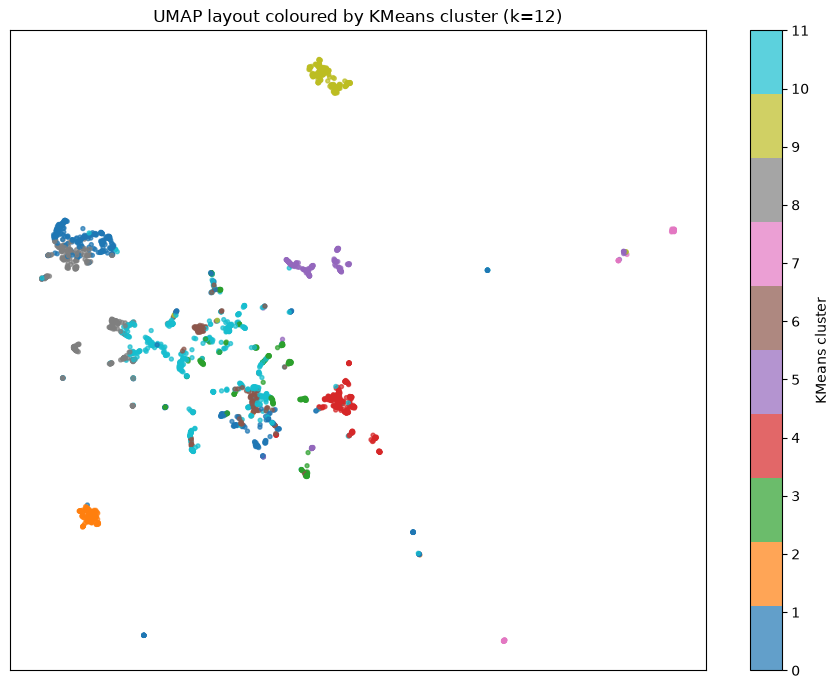

In [17]:
# Final clustering at best_k; overlay on the UMAP layout (static matplotlib — renders inline).
meta["cluster"] = KMeans(n_clusters=best_k, random_state=RANDOM_STATE,
                         n_init=10).fit_predict(X).astype(int)
plt.figure(figsize=(9, 7))
sc = plt.scatter(meta["umap_x"], meta["umap_y"], s=8, alpha=0.7,
                 c=meta["cluster"], cmap="tab10")
plt.colorbar(sc, label="KMeans cluster", ticks=range(best_k))
plt.title(f"UMAP layout coloured by KMeans cluster (k={best_k})")
plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()
meta["cluster"] = meta["cluster"].astype(str)  # back to str for the crosstab below


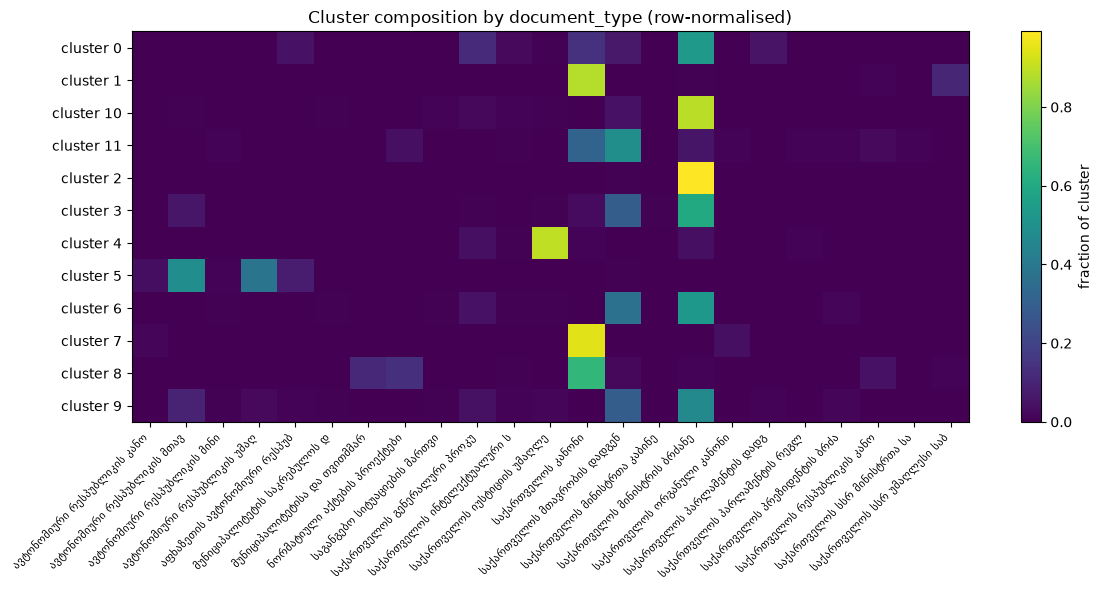

In [18]:
# How do clusters map onto document types? Row-normalised heatmap (each cluster sums to 1).
ct = pd.crosstab(meta["cluster"], meta["type_short"])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(ct_norm.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(ct_norm.columns)))
ax.set_xticklabels(ct_norm.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(ct_norm.index)))
ax.set_yticklabels([f"cluster {i}" for i in ct_norm.index])
ax.set_title("Cluster composition by document_type (row-normalised)")
fig.colorbar(im, ax=ax, label="fraction of cluster")
plt.tight_layout(); plt.show()


## 7 · Similarity structure

Because the vectors are unit-normalized, cosine similarity is just the dot product. We look at
two things: how tightly each chunk sits next to its nearest neighbour, and how self-similar each
document_type is versus the rest of the corpus.

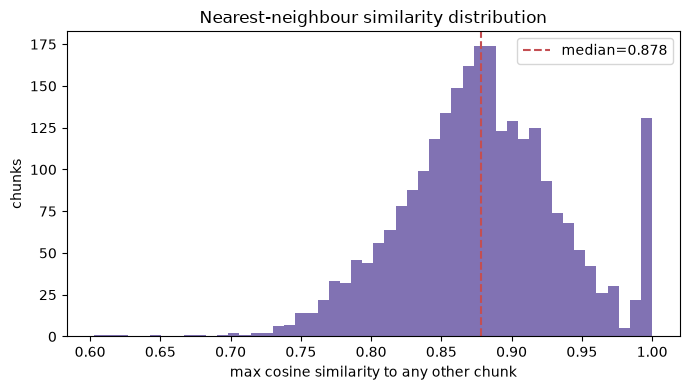

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# Nearest-neighbour cosine for every chunk (exclude self). Block-wise to stay memory-light.
def nn_cosine(X, block=512):
    out = np.empty(len(X), dtype=np.float32)
    for s in range(0, len(X), block):
        sims = X[s:s+block] @ X.T          # (block, N); vectors already unit-norm
        for i in range(sims.shape[0]):
            sims[i, s + i] = -1.0           # mask self
        out[s:s+block] = sims.max(axis=1)
    return out

nn = nn_cosine(X)
plt.figure(figsize=(7, 4))
plt.hist(nn, bins=50, color="#8172b3")
plt.axvline(np.median(nn), ls="--", c="#c44e52", label=f"median={np.median(nn):.3f}")
plt.xlabel("max cosine similarity to any other chunk")
plt.ylabel("chunks"); plt.title("Nearest-neighbour similarity distribution")
plt.legend(); plt.tight_layout(); plt.show()


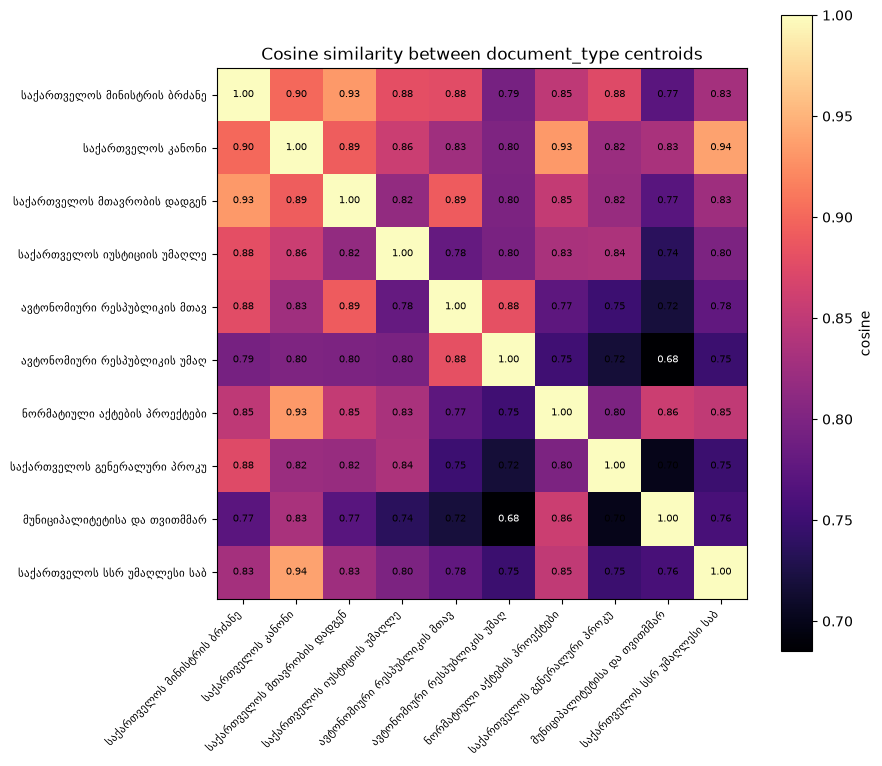

In [20]:
# Mean centroid cosine between document types — block structure = semantically distinct families.
top_types = meta["type_short"].value_counts().head(10).index.tolist()
centroids = np.vstack([X[(meta["type_short"] == t).values].mean(axis=0) for t in top_types])
centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)
sim = cosine_similarity(centroids)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(sim, cmap="magma", vmin=sim.min(), vmax=1.0)
ax.set_xticks(range(len(top_types))); ax.set_yticks(range(len(top_types)))
ax.set_xticklabels(top_types, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(top_types, fontsize=8)
for i in range(len(top_types)):
    for j in range(len(top_types)):
        ax.text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center",
                color="white" if sim[i,j] < 0.7 else "black", fontsize=7)
ax.set_title("Cosine similarity between document_type centroids")
fig.colorbar(im, ax=ax, label="cosine"); plt.tight_layout(); plt.show()


---
### Notes & extensions
- **Re-run on a filtered slice:** pass a `scroll_filter` to `load_all` (e.g. only `status == "in_force"`)
  to visualise a sub-corpus.
- **Sparse vectors** (`"sparse"`) are high-dimensional and not meaningfully projectable to 2D — this
  notebook covers the dense side only.
- Projections are seeded (`RANDOM_STATE=42`) so layouts are reproducible across runs.
- If Georgian labels show as boxes in the static matplotlib charts, rely on the interactive Plotly
  charts (they render the font correctly) or install a Georgian-capable font.
